In [ ]:
from AutoEncoderObjects import EntropyLimitedAutoencoder
import pickle
import torch

from LoadingDefault import LoadAudiosTest
import matplotlib.pyplot as plt

from IPython.display import Audio
from preprocessing import Reconstruction

c:\Users\jpeir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
with open("DEF MODELS/" + "metadatos_modelos.pkl", "rb") as f:
    lista_cargada = pickle.load(f)
    
mse_songs = EntropyLimitedAutoencoder()
nlpd_songs = EntropyLimitedAutoencoder()
msssim_songs = EntropyLimitedAutoencoder()

mse_noise = EntropyLimitedAutoencoder()
nlpd_noise = EntropyLimitedAutoencoder()
msssim_noise = EntropyLimitedAutoencoder()

mse_songs.load_state_dict(torch.load("DEF MODELS/MSE-songs.pth", map_location=torch.device('cpu')))
nlpd_songs.load_state_dict(torch.load("DEF MODELS/NLPD-songs.pth", map_location=torch.device('cpu')))
msssim_songs.load_state_dict(torch.load("DEF MODELS/MSSSIM-songs.pth", map_location=torch.device('cpu')))

mse_noise.load_state_dict(torch.load("DEF MODELS/MSE-noise.pth", map_location=torch.device('cpu')))
nlpd_noise.load_state_dict(torch.load("DEF MODELS/NLPD-noise.pth", map_location=torch.device('cpu')))
msssim_noise.load_state_dict(torch.load("DEF MODELS/MSSSIM-noise.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

In [3]:
XX, metadata = LoadAudiosTest(limit=20)

c:\Users\jpeir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


In [10]:
def ReBuild(model, data_list):
    return model.decode(model.encode(torch.stack(data_list).unsqueeze(1)))

In [13]:
mse_prove = ReBuild(mse_songs, XX)

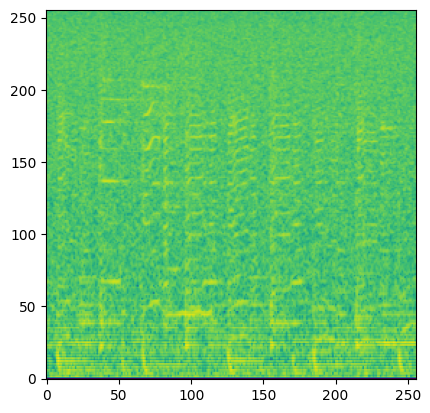

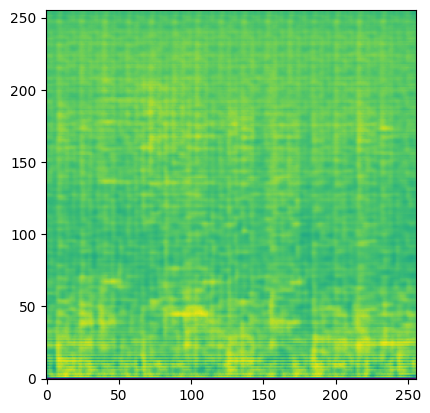

In [24]:
plt.imshow(XX[5].detach().numpy(),origin='lower')
plt.show()

plt.imshow(mse_prove[5][0].detach().numpy(),origin='lower')
plt.show()

In [23]:
reconstruction = Reconstruction(XX[5], maxi=metadata[5]["maximum"], mini=metadata[5]["minimum"])
Audio(reconstruction.detach().numpy(), rate=16000)

In [27]:
reconstruction_rebuild = Reconstruction(mse_prove[5][0], maxi=metadata[5]["maximum"], mini=metadata[5]["minimum"])
Audio(reconstruction_rebuild.detach().numpy(), rate=16000)

c:\Users\jpeir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(
